In [14]:
!pip install -q lightgbm

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [15]:
df = pd.read_csv("/kaggle/input/datasets/yashvasudeva/comments/all_categories_comments_labeled.csv",engine="python")
print(f"Loaded {len(df)} rows.")

Loaded 393832 rows.


In [16]:
df = df[["text", "sentiment"]].dropna()
df["text"] = df["text"].astype(str)
df["sentiment"] = df["sentiment"].astype(str).str.strip().str.lower()

print("Label distribution:\n", df["sentiment"].value_counts())

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^a-z0-9\s']", " ", text)   # keeps "don't", "isn't", "not" intact
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.len() > 0]

Label distribution:
 sentiment
positive    153118
neutral     134670
negative    105948
Name: count, dtype: int64


In [17]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["sentiment"])
print(dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

{'negative': 0, 'neutral': 1, 'positive': 2}


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    stratify=df["label"],
    random_state=42,
)

In [19]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from scipy.sparse import hstack

# Remove negation-bearing words from the stop list — critical for sentiment
NEGATIONS = {"not", "no", "nor", "never", "none", "cannot", "can't", "won't",
             "don't", "doesn't", "didn't", "isn't", "aren't", "wasn't", "weren't",
             "wouldn't", "couldn't", "shouldn't", "hasn't", "haven't", "hadn't",
             "n't", "but", "however", "though"}
custom_stop_words = ENGLISH_STOP_WORDS - NEGATIONS

# Word-level: unigrams + bigrams + trigrams (catches "not that good")
word_vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True,
    stop_words=list(custom_stop_words),
)

# Char-level: robust to typos, elongated words ("sooo good"), informal spelling
char_vectorizer = TfidfVectorizer(
    max_features=15000,
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True,
)

X_train_word = word_vectorizer.fit_transform(X_train)
X_test_word = word_vectorizer.transform(X_test)

X_train_char = char_vectorizer.fit_transform(X_train)
X_test_char = char_vectorizer.transform(X_test)

X_train_tfidf = hstack([X_train_word, X_train_char]).tocsr()
X_test_tfidf = hstack([X_test_word, X_test_char]).tocsr()

print(f"Combined feature dimension: {X_train_tfidf.shape[1]}")

Combined feature dimension: 30000


In [20]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_tfidf, y_train, test_size=0.15, stratify=y_train, random_state=42
)

clf = lgb.LGBMClassifier(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=30,       # regularization: avoid leaves fit to a few noisy rows
    feature_fraction=0.7,       # sample features per tree — key with 30k sparse features
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_alpha=0.2,
    reg_lambda=0.2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

clf.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(stopping_rounds=40), lgb.log_evaluation(50)],
)

[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 44.740728 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3447804
[LightGBM] [Info] Number of data points in the train set: 263098, number of used features: 28263
[Ligh

LGBMClassifier(bagging_fraction=0.8, bagging_freq=1, class_weight='balanced',
               feature_fraction=0.7, learning_rate=0.03, min_child_samples=30,
               n_estimators=800, n_jobs=-1, num_leaves=63, random_state=42,
               reg_alpha=0.2, reg_lambda=0.2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
              precision    recall  f1-score   support

    negative       0.75      0.79      0.77     21160
     neutral       0.75      0.79      0.77     26426
    positive       0.89      0.81      0.85     29796

    accuracy                           0.80     77382
   macro avg       0.80      0.80      0.80     77382
weighted avg       0.81      0.80      0.80     77382



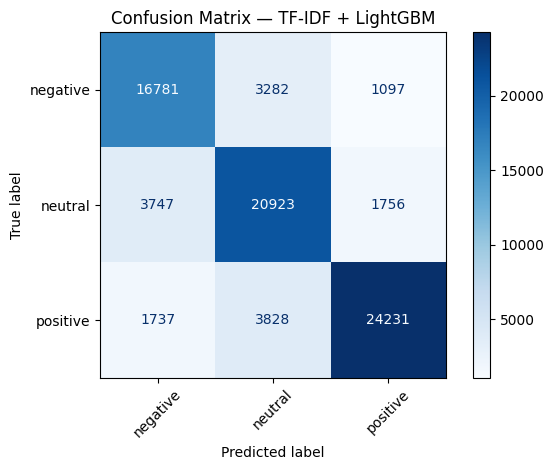

In [21]:
y_pred = clf.predict(X_test_tfidf)

print(classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    zero_division=0,
))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — TF-IDF + LightGBM")
plt.tight_layout()
plt.show()

In [22]:
feature_names = np.concatenate([
    word_vectorizer.get_feature_names_out(),
    char_vectorizer.get_feature_names_out(),
])
importances = clf.feature_importances_
top_idx = np.argsort(importances)[-20:][::-1]

print("Top 20 most important words/n-grams:")
for i in top_idx:
    print(f"  {feature_names[i]:<25} {importances[i]:.1f}")

Top 20 most important words/n-grams:
   i                        452.0
   no                       304.0
   wh                       280.0
   t                        252.0
   a                        238.0
   th                       223.0
   lov                      205.0
  shit                      204.0
  thank                     198.0
  ed                        193.0
   wel                      186.0
  ut                        181.0
   los                      179.0
   wors                     174.0
   or                       169.0
   sad                      165.0
  hell                      162.0
  't                        159.0
   is                       159.0
   my                       155.0


In [23]:
joblib.dump(clf, "lgbm_sentiment_model.joblib")
joblib.dump(word_vectorizer, "tfidf_word_vectorizer.joblib")
joblib.dump(char_vectorizer, "tfidf_char_vectorizer.joblib")
joblib.dump(label_encoder, "label_encoder.joblib")

['label_encoder.joblib']

In [24]:
def predict_sentiment(texts):
    if isinstance(texts, str):
        texts = [texts]
    cleaned = [clean_text(t) for t in texts]
    word_vecs = word_vectorizer.transform(cleaned)
    char_vecs = char_vectorizer.transform(cleaned)
    vecs = hstack([word_vecs, char_vecs]).tocsr()
    preds = clf.predict(vecs)
    return label_encoder.inverse_transform(preds)

In [25]:
!pip install -q mlflow pyngrok

import mlflow
import mlflow.sklearn
import time

# Local SQLite backend (Colab has no server; file-store is deprecated in recent MLflow)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("youtube-comment-sentiment")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 96.2 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 79.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.6/954.6 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 16.8 MB/s eta 0:00:00


2026/07/08 10:47:22 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/08 10:47:22 INFO mlflow.store.db.utils: Updating database tables
2026/07/08 10:47:24 INFO mlflow.tracking.fluent: Experiment with name 'youtube-comment-sentiment' does not exist. Creating a new experiment.


<Experiment: artifact_location='/kaggle/working/mlruns/1', creation_time=1783507644934, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783507644934, lifecycle_stage='active', name='youtube-comment-sentiment', tags={}, trace_location=None, workspace='default'>

In [26]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report
)

def get_all_metrics(y_true, y_pred, label_names, prefix=""):
    """Returns a flat dict of accuracy + per-class + macro/weighted precision/recall/f1."""
    metrics = {}
    metrics[f"{prefix}accuracy"] = accuracy_score(y_true, y_pred)

    for avg in ["macro", "weighted"]:
        p, r, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average=avg, zero_division=0
        )
        metrics[f"{prefix}precision_{avg}"] = p
        metrics[f"{prefix}recall_{avg}"] = r
        metrics[f"{prefix}f1_{avg}"] = f1

    p, r, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(label_names)), zero_division=0
    )
    for i, name in enumerate(label_names):
        metrics[f"{prefix}precision_{name}"] = p[i]
        metrics[f"{prefix}recall_{name}"] = r[i]
        metrics[f"{prefix}f1_{name}"] = f1[i]

    return metrics

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
            metric    train     test  gap (train - test)
          accuracy 0.838977 0.800380            0.038597
   precision_macro 0.837466 0.798242            0.039224
      recall_macro 0.839169 0.799347            0.039822
          f1_macro 0.837356 0.797757            0.039598
precision_weighted 0.843029 0.805472            0.037557
   recall_weighted 0.838977 0.800380            0.038597
       f1_weighted 0.839965 0.801813            0.038152
precision_negative 0.806772 0.753694            0.053078
   recall_negative 0.841458 0.793053            0.048405
       f1_negative 0.823750 0.772873            0.050877
 precision_neutral 0.788

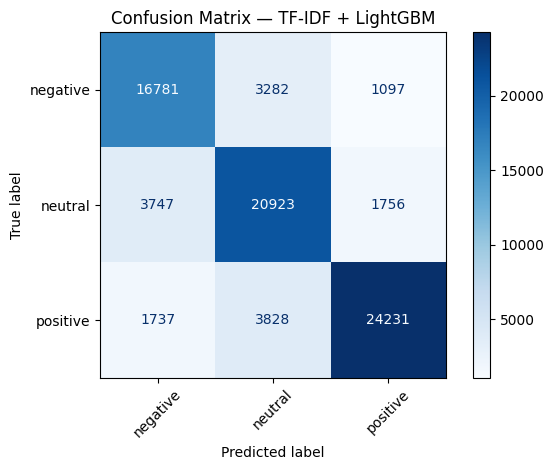

2026/07/08 10:52:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



MLflow run ID: 10891cc5b19446ba858542b7383ac764


In [28]:
with mlflow.start_run(run_name="tfidf_lgbm_word_char"):

    # ---- log config/params ----
    mlflow.log_params({
        "word_max_features": 15000,
        "word_ngram_range": "(1,3)",
        "char_max_features": 15000,
        "char_ngram_range": "(3,5)",
        "n_estimators": clf.n_estimators,
        "learning_rate": clf.learning_rate,
        "num_leaves": clf.num_leaves,
        "min_child_samples": clf.min_child_samples,
        "feature_fraction": clf.feature_fraction,
        "bagging_fraction": clf.bagging_fraction,
        "reg_alpha": clf.reg_alpha,
        "reg_lambda": clf.reg_lambda,
        "class_weight": "balanced",
        "best_iteration": clf.best_iteration_,
        "n_train": X_train_tfidf.shape[0],
        "n_test": X_test_tfidf.shape[0],
        "n_features": X_train_tfidf.shape[1],
    })

    label_names = label_encoder.classes_

    # ---- predictions on both sets ----
    y_train_pred = clf.predict(X_train_tfidf)
    y_test_pred = clf.predict(X_test_tfidf)

    # ---- compute + log metrics for both ----
    train_metrics = get_all_metrics(y_train, y_train_pred, label_names, prefix="train_")
    test_metrics = get_all_metrics(y_test, y_test_pred, label_names, prefix="test_")

    mlflow.log_metrics(train_metrics)
    mlflow.log_metrics(test_metrics)

    # ---- side-by-side comparison table (overfitting check) ----
    comparison_rows = []
    for key in train_metrics:
        test_key = key.replace("train_", "test_")
        comparison_rows.append({
            "metric": key.replace("train_", ""),
            "train": train_metrics[key],
            "test": test_metrics[test_key],
            "gap (train - test)": train_metrics[key] - test_metrics[test_key],
        })
    comparison_df = pd.DataFrame(comparison_rows)
    print(comparison_df.to_string(index=False))

    comparison_df.to_csv("train_vs_test_metrics.csv", index=False)
    mlflow.log_artifact("train_vs_test_metrics.csv")

    # ---- confusion matrix artifact ----
    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Confusion Matrix — TF-IDF + LightGBM")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    mlflow.log_artifact("confusion_matrix.png")
    plt.show()

    # ---- feature importance artifact ----
    feature_names = np.concatenate([
        word_vectorizer.get_feature_names_out(),
        char_vectorizer.get_feature_names_out(),
    ])
    importances = clf.feature_importances_
    top_idx = np.argsort(importances)[-30:][::-1]
    importance_df = pd.DataFrame({
        "feature": feature_names[top_idx],
        "importance": importances[top_idx],
    })
    importance_df.to_csv("feature_importance.csv", index=False)
    mlflow.log_artifact("feature_importance.csv")

    # ---- save model + vectorizers + label encoder as artifacts ----
    joblib.dump(clf, "lgbm_sentiment_model.joblib")
    joblib.dump(word_vectorizer, "tfidf_word_vectorizer.joblib")
    joblib.dump(char_vectorizer, "tfidf_char_vectorizer.joblib")
    joblib.dump(label_encoder, "label_encoder.joblib")
    mlflow.log_artifact("lgbm_sentiment_model.joblib")
    mlflow.log_artifact("tfidf_word_vectorizer.joblib")
    mlflow.log_artifact("tfidf_char_vectorizer.joblib")
    mlflow.log_artifact("label_encoder.joblib")

    # ---- log the model in MLflow's native LightGBM flavor ----
    import mlflow.lightgbm
    mlflow.lightgbm.log_model(clf, artifact_path="lgbm_model")

    run_id = mlflow.active_run().info.run_id
    print(f"\nMLflow run ID: {run_id}")

In [ ]:
from pyngrok import ngrok

# Get a free authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
# ngrok.set_auth_token("YOUR_TOKEN_HERE")

get_ipython().system_raw("mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000 &")
time.sleep(3)
public_url = ngrok.connect(5000)
print(f"MLflow UI: {public_url}")